(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

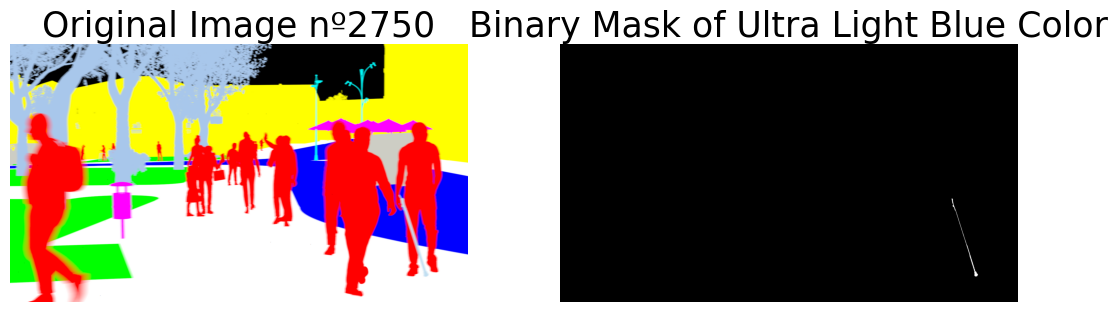

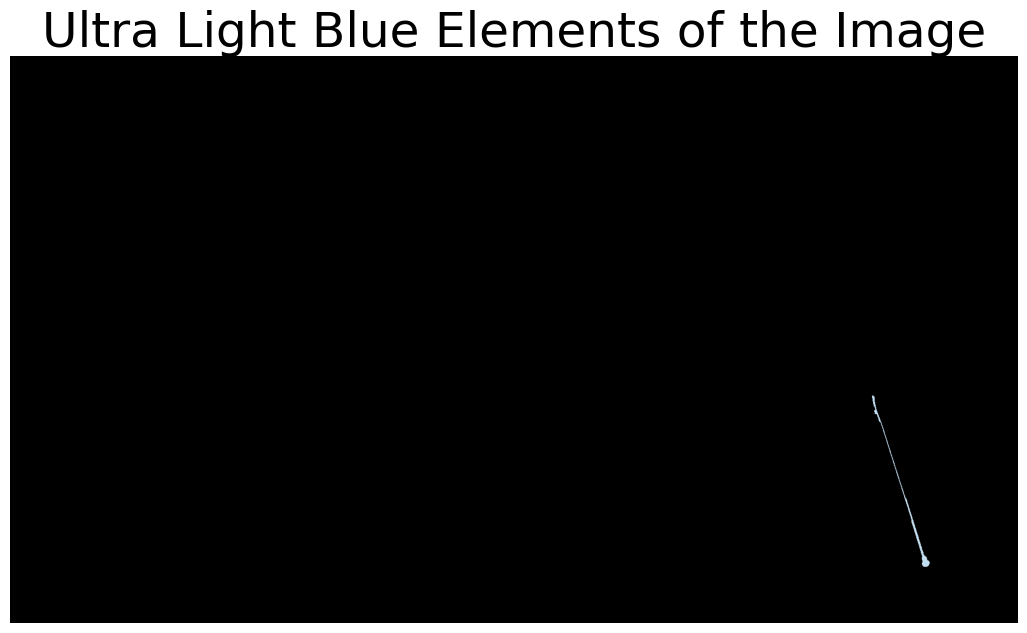

In [ ]:
import sys
import os

# Adicione o caminho da pasta raiz do projeto ao sys.path
sys.path.append(os.path.abspath('/home/renato/Work/pucpr_pibic_semantic_segmentation/'))
# sys.path.append(os.path.abspath('/home/santiago/Doctorado/Entrenamientos/pucpr_pibic_semantic_segmentation-main/'))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

### Refatoração: Processo de Separação para Ultra Light Blue

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
# cv.imshow("Inspect Image", hsv_img)
# cv.waitKey(0)
# cv.destroyAllWindows()

# Segmentation by Limits
# Define limits for Ultra Light Blue Color >> HSV (H:90, S:40, V:230) to (H:105, S:60, V:245)
lower_bound = np.array([90, 40, 230])  # Hue, Saturation, Value
upper_bound = np.array([105, 60, 245]) # Hue, Saturation, Value

# Create binary mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# Remove noise
contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
clean_mask = np.zeros_like(mask)

# Filter by minimum area
min_area = 50
for contour in contours:
    if cv.contourArea(contour) > min_area:
        cv.drawContours(clean_mask, [contour], -1, 255, -1)

mask = clean_mask

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask of Ultra Light Blue Color",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotting result
plt.figure(figsize=[13,13])
plt.imshow(result[:,:,::-1])
plt.title("Ultra Light Blue Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')

In [55]:
# Run the previous code block to inspect
# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
cv.imshow("Inspect Image", hsv_img)
# cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

In [78]:
# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
# cv.imshow("Inspect Image", hsv_img)
cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

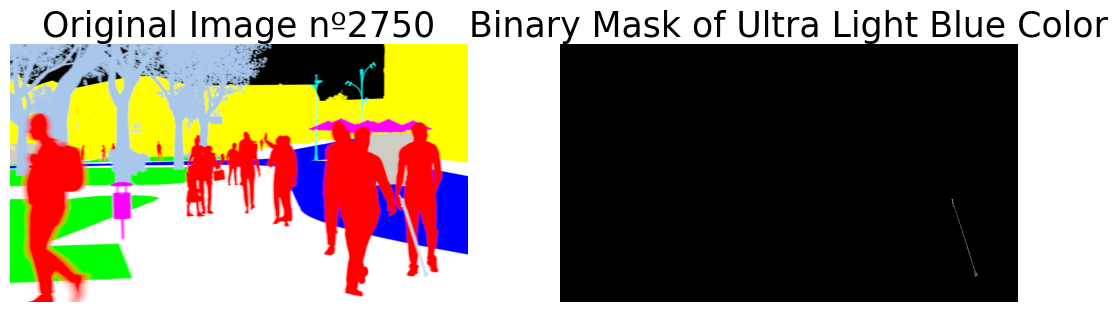

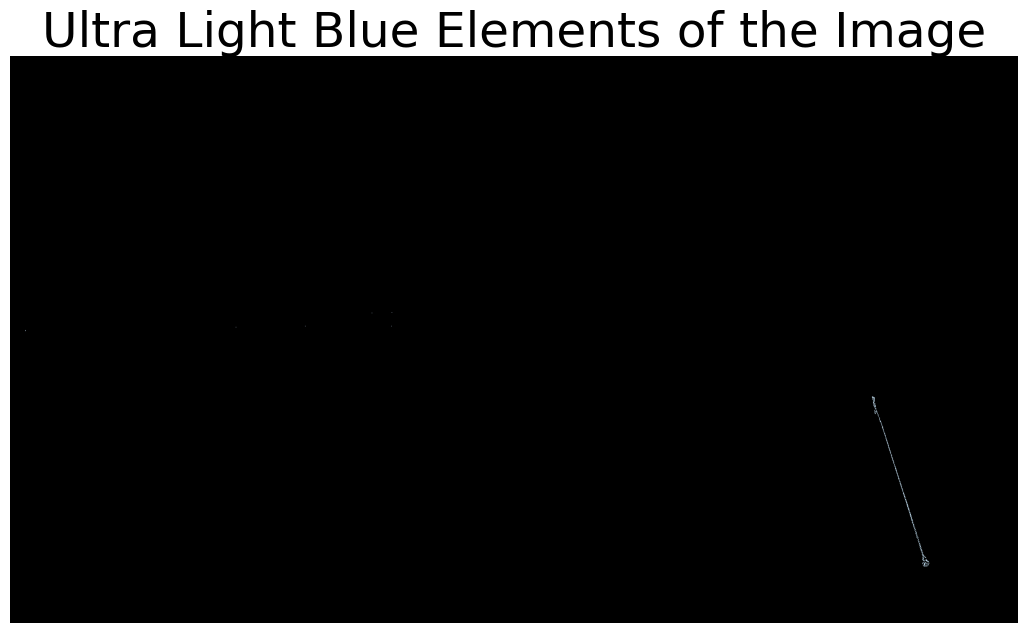

In [43]:
# Using Segmentation by Euclidean Distance
import sys
import os

# Adicione o caminho da pasta raiz do projeto ao sys.path
sys.path.append(os.path.abspath('/home/renato/Work/pucpr_pibic_semantic_segmentation/'))
# sys.path.append(os.path.abspath('/home/santiago/Doctorado/Entrenamientos/pucpr_pibic_semantic_segmentation-main/'))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
# import os


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

### Refatoração: Processo de Separação para LIGHT ORANGE 20

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
# cv.imshow("Inspect Image", hsv_img)
# cv.waitKey(0)
# cv.destroyAllWindows()

# # Segmentation by Limits
# # Define limits for Light Orange Color >> HSV (H:90, S:40, V:230) to (H:105, S:51, V:245)
# lower_bound = np.array([90, 40, 230])  # Hue, Saturation, Value
# upper_bound = np.array([105, 51, 245]) # Hue, Saturation, Value

# # Create binary mask
# mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# Segmentation by Euclidean Distance
# Define target color in HSV (e.g., ultra light blue)
target_color = np.array([102, 47, 238])  # Hue, Saturation, Value

# Calculate Euclidean distance from the target color
distance = np.sqrt(np.sum((hsv_img - target_color) ** 2, axis=-1))

# Apply threshold to create the mask
threshold = 5  # Define acceptable distance
mask = (distance < threshold).astype(np.uint8) * 255


# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask of Ultra Light Blue Color",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotting result
plt.figure(figsize=[13,13])
plt.imshow(result[:,:,::-1])
plt.title("Ultra Light Blue Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')

In [37]:
# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
cv.imshow("Inspect Image", hsv_img)
# cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

In [44]:
# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
# cv.imshow("Inspect Image", hsv_img)
cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()